## 2. Demand Estimation

We will estimate a logit-style demand model using linear regression. The model is:

$$
\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{price}p_{bt} + \beta_{rating}r_{bt} + \sum_{\ell=1}^L \beta_\ell x_{bt\ell} + \epsilon_{bt}.
$$

Here:

- $b$ indexes brands
- $t$ indexes years
- $s_{bt}$ is `brand_share`
- $p_{bt}$ is `avg_price`
- $r_{bt}$ is `avg_rating`
- $x_{bt\ell}$ are the product characteristics
- $\alpha_t$ are year dummy coefficients
- $\gamma_b$ are brand dummy coefficients
- $\beta_{price}$ is **one constant price coefficient**, shared by all brands and all years

That last point matters: do **not** estimate a different price coefficient for every brand-year. We do not have enough information for that, and it would make the cost calculation impossible to interpret.

Use `pd.get_dummies(..., drop_first=True)` for brand and year dummies. The dropped brand and dropped year become the reference categories, so all dummy coefficients are interpreted relative to those omitted categories.

Questions:

1. What is the estimated price coefficient, $\hat{\beta}_{price}$?
2. Is it negative? Why is that important?
3. Which product features are associated with higher demand?
4. Which brand dummy coefficients are largest? Remember that these are interpreted relative to the dropped brand.
5. Which year dummy coefficients are largest? Remember that these are interpreted relative to the dropped year.
6. What is the model's $R^2$?

This part of the work is the **data scientist** role: turning the cleaned data into a model that can be used for prediction and interpretation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv('air_fryers_clean_brand_year.csv')

In [2]:
df['log_brand_share'] = np.log(df['brand_share'])

feature_cols = [
    col for col in df.columns 
    if col.endswith('_share') and col not in ['brand_share', 'log_brand_share']
]

In [3]:
brand_dummies = pd.get_dummies(df['brand'], prefix='brand', drop_first=True)
year_dummies = pd.get_dummies(df['year'], prefix='year', drop_first=True)

In [4]:
X = pd.concat([
    df[['avg_price', 'avg_rating'] + feature_cols],
    brand_dummies,
    year_dummies
], axis=1).astype(float)

X.columns = X.columns.astype(str)

y = df['log_brand_share']

In [5]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print('R^2:', r2)

R^2: 0.7634539500914356


In [7]:
coef_table = pd.DataFrame({
    'variable': ['intercept'] + list(X.columns),
    'coefficient': [model.intercept_] + list(model.coef_)
})

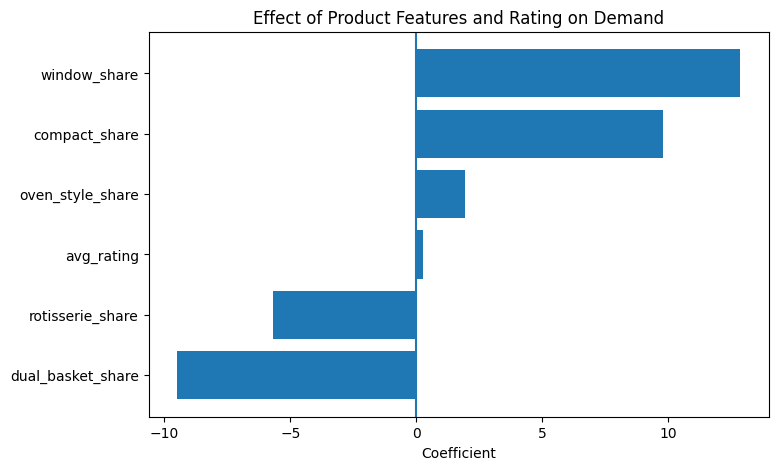

In [8]:
vars_to_plot = ['avg_rating'] + feature_cols

effects = coef_table[
    coef_table['variable'].isin(vars_to_plot)
].sort_values('coefficient')

plt.figure(figsize=(8,5))
plt.barh(effects['variable'], effects['coefficient'])
plt.axvline(0)

plt.xlabel('Coefficient')
plt.title('Effect of Product Features and Rating on Demand')

plt.show()

This visualization helps show which product characteristics are most important in driving consumer demand.

In [9]:
price_coef = coef_table.loc[
    coef_table['variable'] == 'avg_price', 
    'coefficient'
].iloc[0]

print('Price coefficient:', price_coef)

Price coefficient: -0.0376676529842942


In [10]:
print(
    coef_table[coef_table['variable'].isin(feature_cols)]
    .sort_values('coefficient', ascending=False)
)

            variable  coefficient
7       window_share    12.880298
3      compact_share     9.815304
5   oven_style_share     1.941774
6   rotisserie_share    -5.674054
4  dual_basket_share    -9.509686


In [11]:
print(
    coef_table[coef_table['variable'].str.startswith('brand_')]
    .sort_values('coefficient', ascending=False)
)

             variable  coefficient
9     brand_cuisinart     6.422436
13        brand_ninja     5.838705
12  brand_instant_pot     4.626260
11   brand_gowise usa     3.938996
15        brand_oster     3.928074
14       brand_nuwave     3.544883
8        brand_cosori     2.551946
16      brand_ultrean     0.942399
10         brand_dash     0.176655


In [12]:
print(
    coef_table[coef_table['variable'].str.startswith('year_')]
    .sort_values('coefficient', ascending=False)
)

     variable  coefficient
17  year_2020     0.119071
18  year_2021     0.041900
20  year_2023    -0.003307
19  year_2022    -0.098860


## Part 2 Answers

1) The estimated price coefficient is −0.0377. This means that when price is going up, the market share is going down. Because the log of the market share is being used, it is showing a proportional decrease in demand as price increases.

2) Yes, it is negative. It is important because it aligns with real life expectations of the market. When something gets more expensive, it is bought less. Seeing a negative coefficient tells us that the model aligns with typical market behavior.

3) The features that are higher in demand are the ones with positive coefficients. In this case, window share, compact share, and oven style share all increase demand, so products with these features do better in terms of market share. On the other hand, rotisserie share and dual basket share have negative coefficients, which tells us that those features are not as popular to most customers.

4) The brand dummy coefficients show how each brand compares to the reference brand. The biggest ones are Cuisinart, Ninja, and Instant Pot, which means these brands have higher demand than baseline brands. This comes down to things like brand reputation, trust, or overall popularity.

5) The year dummy coefficients show how demand changes over time. The highest ones are for 2020 and 2021, which means that demand was stronger in those years. That makes sense since people were cooking at home more during that time. The later years are lower, which suggests demand dropped a bit after that.

6) The model’s R² is 0.763, meaning it explains about 76.3% of the variation in market share. That’s a solid number. Overall the model is doing a pretty good job of capturing what drives demand.


## ChatGPT was used to help formulate code. Markdowns are all my words.